# Gene Expression PTR analysis
March 21, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import glob

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/'

file_paths = glob.glob(f'{outdir}/*_meta_*.csv')


In [24]:
from cc_src.geneset import get_deconvolved_geneset

geneset = get_deconvolved_geneset()[['gene']].copy()
geneset['ptr'] = None

In [26]:

for filepath in file_paths:
    row = pd.read_csv(filepath).iloc[0]
    ptr = row.ptr
    orf_name = row['Unnamed: 0']
    geneset.loc[orf_name, 'ptr'] = ptr

0

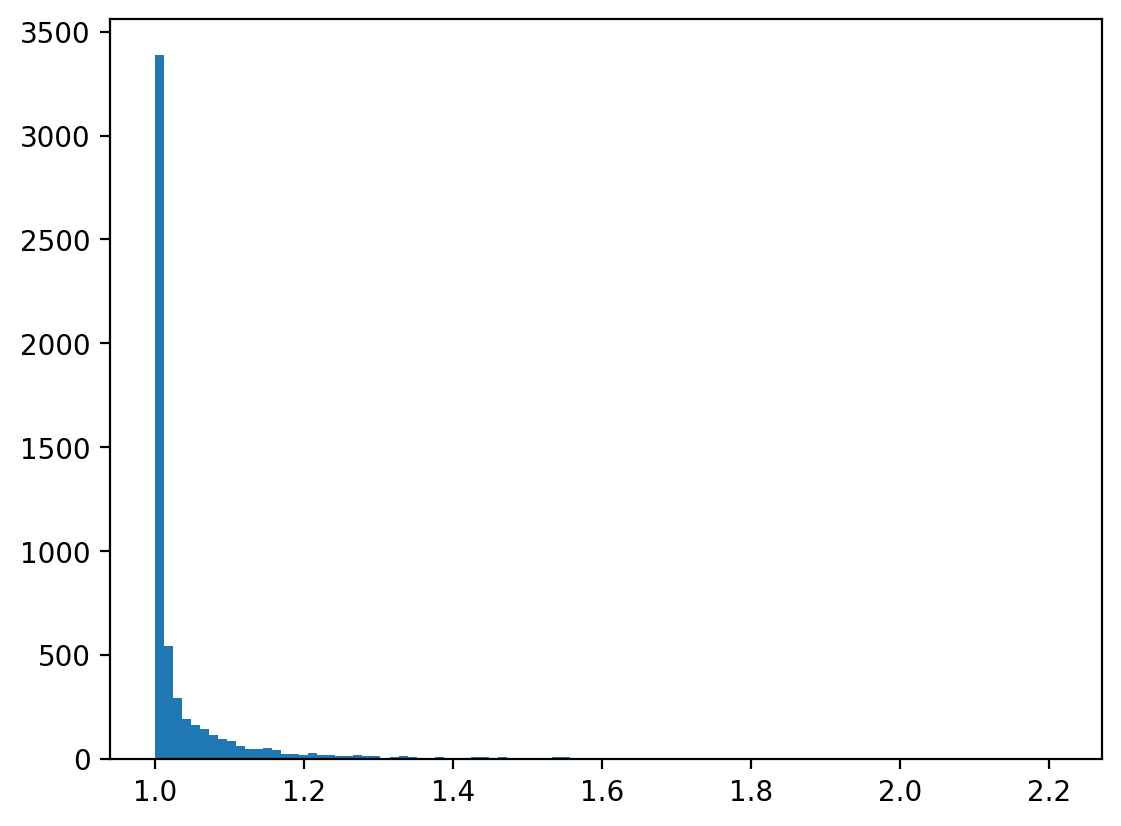

In [31]:
plt.hist(geneset['ptr'].dropna(), bins=100)
0

In [52]:
# Now get the PTR for the raw gene expression data
from src.config import read_yl_vst_data_rep, load_yl_rg1_vst_config
from src.model import Model

replicate = 1


config = load_yl_rg1_vst_config(replicate)
model = Model(config, "SEO1")

mu0 = config.intervals_wt1[0][0]
rep1_vst_ge_data = read_yl_vst_data_rep(replicate)

from cc_src.peak_to_trough import compute_quantile_ptr
    
# Compute the peak to trough ratio for non recovery timepoints
non_RG1_G = rep1_vst_ge_data[rep1_vst_ge_data.columns[rep1_vst_ge_data.columns > mu0]]
g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
   0.2, 0.8), 1, non_RG1_G)


In [58]:
rep1_raw_ptrs = rep1_vst_ge_data[[]].copy()
rep1_raw_ptrs['g_ptr'] = g_ptrs

In [62]:
joined_ptr_comparison = rep1_raw_ptrs.join(geneset).dropna()

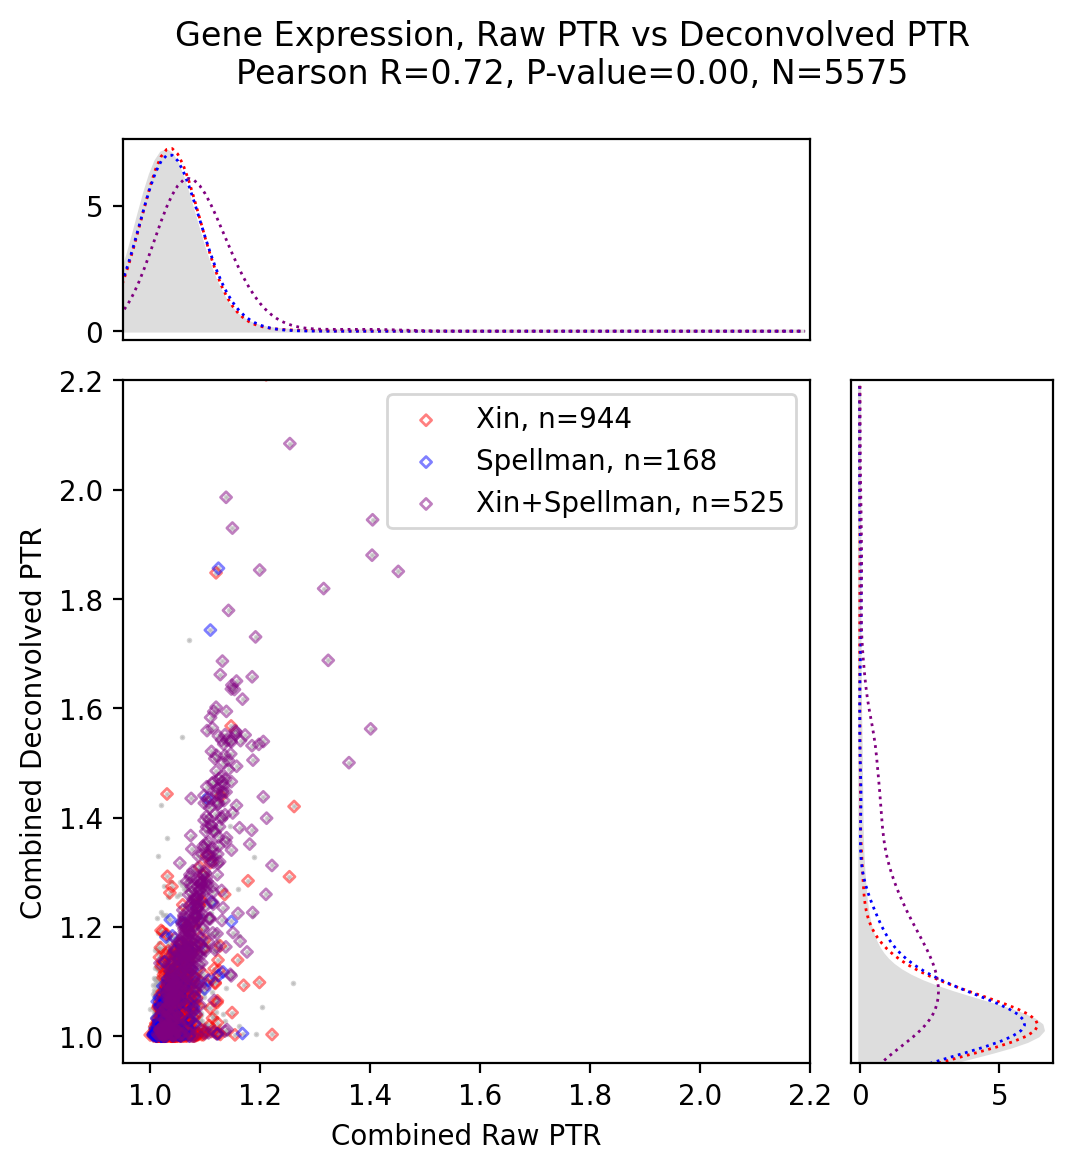

In [155]:
from cc_src.peak_to_trough_anaysis import plot_comparison_scatter, filter_index, \
    plot_comparison_ptr, create_highlighted_orfs_array

x, y = joined_ptr_comparison.g_ptr, joined_ptr_comparison.ptr

highlighted_orfs = create_highlighted_orfs_array(joined_ptr_comparison)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(0.95, 2.2), ylim=(0.95, 2.2),
                   title="Gene Expression, Raw PTR vs Deconvolved PTR",
                   xlabel="Combined Raw PTR",
                   ylabel="Combined Deconvolved PTR")


In [85]:
# Compare GE to xin ge ptrs next, "should" be similar, but may be a bit different. 
# the marginals should be clear for sanity checking

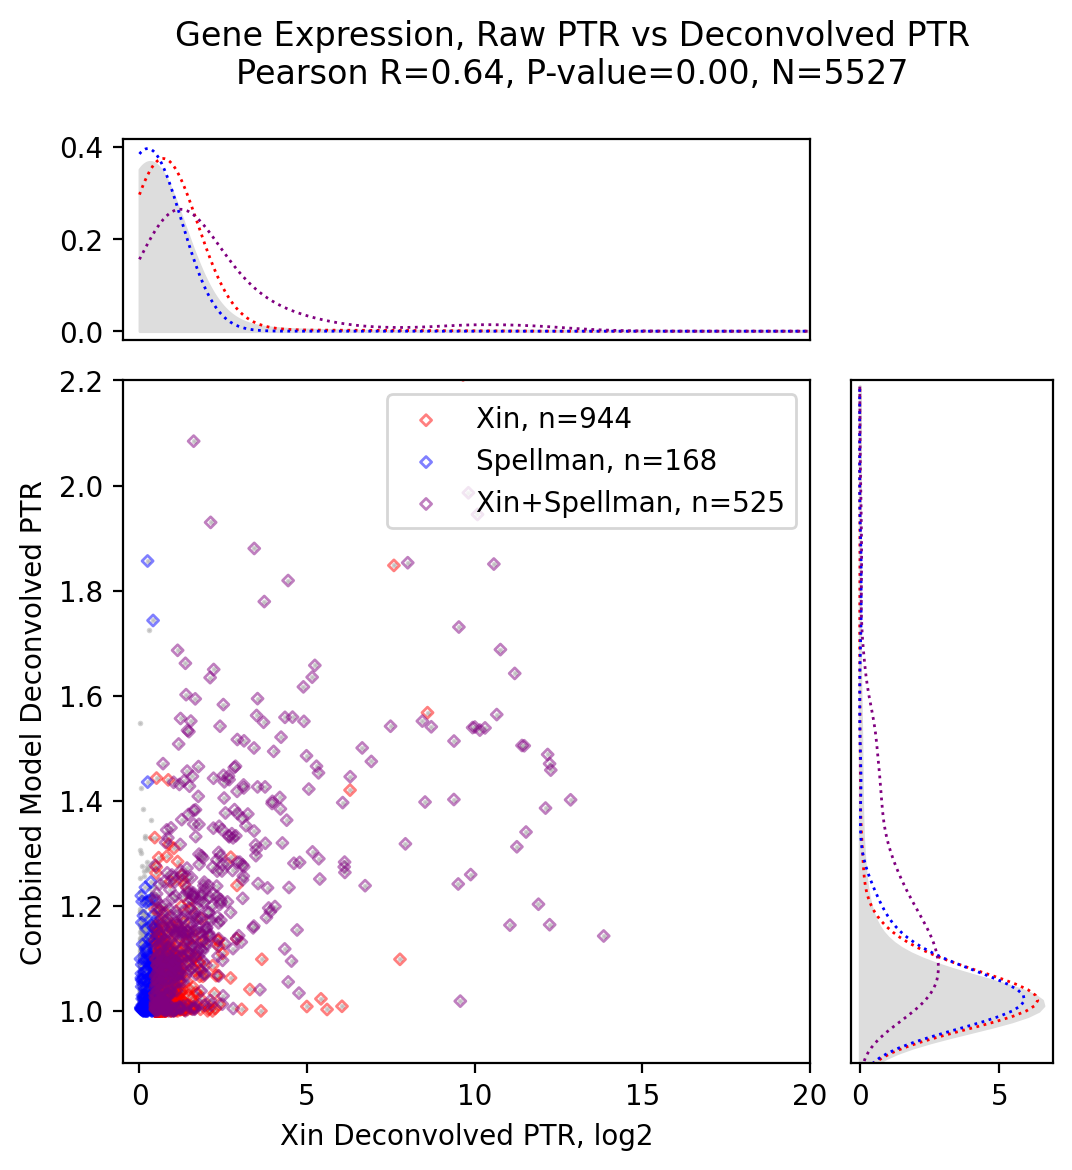

In [154]:

gene_as = pd.read_csv('datasets/datasets_from_web_deconvolution.cs.duke.edu/gene_associated.tsv', 
                      sep='\t')
xin_ptrs_df = gene_as.set_index('Systematic Name')[['Deconvolved PTR (80pt/20pt)']].rename(
columns={'Deconvolved PTR (80pt/20pt)': 'xin_ptr'})
ptrs_compared_xin_df = xin_ptrs_df.join(joined_ptr_comparison)
ptrs_compared_xin_df = ptrs_compared_xin_df.dropna()

x, y = ptrs_compared_xin_df.xin_ptr, ptrs_compared_xin_df.ptr
x = np.log2(x)

highlighted_orfs = create_highlighted_orfs_array(ptrs_compared_xin_df)

plot_comparison_ptr(x, y, highlighted_orfs, xlim=(-0.5, 20), ylim=(0.9, 2.2), bw=(1, 0.05), 
                   title="Gene Expression, Raw PTR vs Deconvolved PTR",
                   xlabel="Xin Deconvolved PTR, log2",
                   ylabel="Combined Model Deconvolved PTR")

